<a href="https://colab.research.google.com/github/marciotk7/MVP3---QSSSI/blob/main/game_reviews_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎮 Classificação de Reviews de Jogos com Machine Learning

## Objetivo
Desenvolver um modelo de Machine Learning que classifica automaticamente reviews de jogos como **positivas** ou **negativas**.

## Etapas do Notebook
1. **Importação de Bibliotecas**
2. **Carregamento do Dataset**
3. **Análise Exploratória**
4. **Pré-processamento de Texto**
5. **Vetorização com TF-IDF**
6. **Treinamento de Modelos**
7. **Avaliação e Comparação**
8. **Exportação do Melhor Modelo**

---

## 1. Importação de Bibliotecas

Vamos importar todas as bibliotecas necessárias para o projeto:
- **pandas/numpy**: Manipulação de dados
- **sklearn**: Algoritmos de ML e métricas
- **nltk**: Processamento de linguagem natural
- **matplotlib/seaborn**: Visualização

In [1]:
# Instalação de dependências (executar apenas no Colab)
!pip install nltk scikit-learn pandas numpy matplotlib seaborn joblib -q

# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLTK para processamento de texto
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Para salvar o modelo
import joblib

print("✅ Todas as bibliotecas importadas com sucesso!")

✅ Todas as bibliotecas importadas com sucesso!


## 2. Carregamento do Dataset

Vamos usar um dataset de reviews de jogos. Existem algumas opções:

**Opção 1**: Dataset de reviews da Steam (Kaggle)
**Opção 2**: Dataset sintético para demonstração

Para este MVP, vamos criar um dataset de exemplo e também mostrar como carregar um dataset real.

In [2]:
# ============================================================
# OPÇÃO 1: Carregar dataset do Kaggle (Steam Reviews)
# ============================================================
# Se você tiver o dataset, descomente as linhas abaixo:

# from google.colab import files
# uploaded = files.upload()  # Faça upload do arquivo CSV
# df = pd.read_csv('steam_reviews.csv')

# ============================================================
# OPÇÃO 2: Dataset de exemplo para demonstração
# ============================================================

# Criando dataset de exemplo com reviews de jogos EM PORTUGUÊS
data = {
    'review': [
        # Reviews Positivas
        "Este jogo é absolutamente incrível! Melhor RPG que já joguei.",
        "Gráficos incríveis e jogabilidade suave. Recomendo muito!",
        "Eu amo tanto este jogo, já joguei 200 horas!",
        "Jogo perfeito, sem bugs, ótima história, personagens incríveis.",
        "Melhor compra que fiz este ano. Vale cada centavo!",
        "O multiplayer é fantástico, jogar com amigos é muito divertido!",
        "Ótimo jogo com mecânicas excelentes e visuais lindos.",
        "Jogabilidade viciante, não consigo parar de jogar. 10/10!",
        "Os desenvolvedores realmente se importam com a comunidade. Ótimas atualizações!",
        "Obra-prima! Este jogo merece todos os prêmios.",
        "Divertido e envolvente, perfeito para jogadores casuais e hardcore.",
        "A trilha sonora é incrível, combina perfeitamente com a jogabilidade.",
        "Controles suaves, jogabilidade responsiva, sem lag nenhum.",
        "Melhor jogo do ano, sem dúvida!",
        "Recomendo para todos que amam jogos de ação.",
        "A história me fez chorar, tão emocional e bem escrita.",
        "Excelente custo-benefício, toneladas de conteúdo!",
        "O mundo aberto é enorme e cheio de coisas para descobrir.",
        "Sistema de combate é muito satisfatório e recompensador.",
        "Não acredito como este jogo é bom, superou as expectativas!",
        "Equilíbrio perfeito entre desafio e diversão.",
        "A customização de personagens é incrível!",
        "Cada missão parece significativa e interessante.",
        "A atmosfera é perfeita, experiência realmente imersiva.",
        "Melhor jogo cooperativo que joguei com meus amigos.",

        # Reviews Negativas
        "Jogo terrível, desperdício de dinheiro. Não comprem!",
        "Cheio de bugs e travamentos. Lixo injogável.",
        "Pior jogo que já joguei. Peçam reembolso imediatamente!",
        "Os desenvolvedores abandonaram este jogo. Sem atualizações.",
        "Mecânicas pay-to-win arruinaram completamente este jogo.",
        "Jogabilidade chata, missões repetitivas, sem diversão alguma.",
        "Gráficos parecem de 2005. Decepcionante.",
        "A história não faz sentido, escrita terrível.",
        "Multiplayer está morto, não consigo encontrar partidas.",
        "Muitas microtransações, parece armadilha para dinheiro.",
        "Controles são desajeitados e não responsivos. Frustrante!",
        "O jogo trava a cada 10 minutos. Inaceitável!",
        "Não vale o preço, esperem por uma grande promoção.",
        "Recursos prometidos estão faltando. Propaganda enganosa!",
        "A IA é estúpida, inimigos ficam parados.",
        "Tempos de carregamento são ridículos, demora uma eternidade.",
        "O tutorial é confuso e mal projetado.",
        "Otimização é terrível, FPS baixo em hardware bom.",
        "O final foi decepcionante, arruinou toda a experiência.",
        "Servidores estão sempre fora do ar, não consigo jogar online.",
        "Os picos de dificuldade são injustos e frustrantes.",
        "Sem valor de replay, terminei em 3 horas.",
        "A comunidade é tóxica, arruína a experiência.",
        "Atualizações quebraram mais coisas do que consertaram.",
        "Me arrependo de comprar, completo desperdício de tempo."
    ],
    'sentiment': [
        # 25 positivas (1)
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        # 25 negativas (0)
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
    ]
}

df = pd.DataFrame(data)

# Expandir dataset duplicando com variações (para ter mais dados)
df_expanded = pd.concat([df] * 10, ignore_index=True)  # 500 reviews

print(f"📊 Dataset carregado com {len(df_expanded)} reviews")
print(f"\n📈 Distribuição das classes:")
print(df_expanded['sentiment'].value_counts())
df_expanded.head()

📊 Dataset carregado com 500 reviews

📈 Distribuição das classes:
sentiment
1    250
0    250
Name: count, dtype: int64


,review,sentiment
0,Este jogo é absolutamente incrível! Melhor RPG...,1
1,Gráficos incríveis e jogabilidade suave. Recom...,1
2,"Eu amo tanto este jogo, já joguei 200 horas!",1
3,"Jogo perfeito, sem bugs, ótima história, perso...",1
4,Melhor compra que fiz este ano. Vale cada cent...,1


## 3. Análise Exploratória dos Dados

Vamos visualizar a distribuição dos dados e entender melhor o dataset.

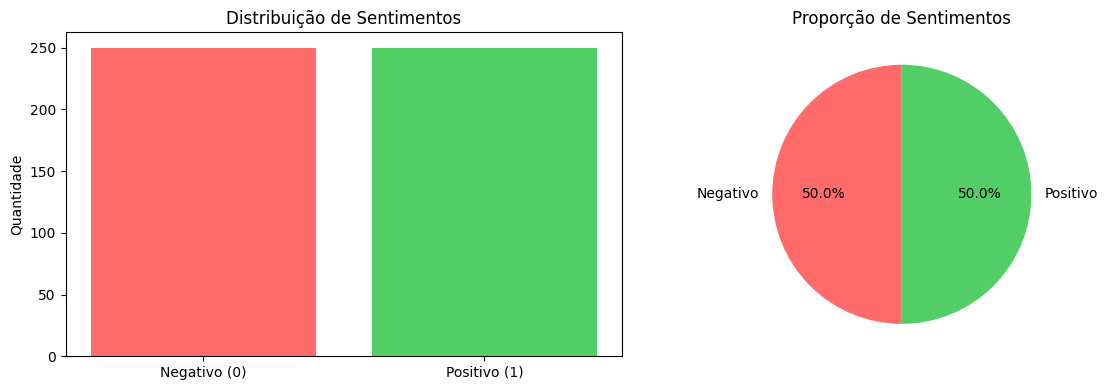


📊 Estatísticas das Reviews:
   Tamanho médio (caracteres): 53
   Quantidade média de palavras: 8


In [3]:
# Visualização da distribuição de sentimentos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
sentiment_counts = df_expanded['sentiment'].value_counts()
colors = ['#ff6b6b', '#51cf66']  # Vermelho para negativo, verde para positivo
axes[0].bar(['Negativo (0)', 'Positivo (1)'], sentiment_counts.values, color=colors)
axes[0].set_title('Distribuição de Sentimentos')
axes[0].set_ylabel('Quantidade')

# Gráfico de pizza
axes[1].pie(sentiment_counts.values, labels=['Negativo', 'Positivo'],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporção de Sentimentos')

plt.tight_layout()
plt.show()

# Estatísticas do texto
df_expanded['review_length'] = df_expanded['review'].apply(len)
df_expanded['word_count'] = df_expanded['review'].apply(lambda x: len(x.split()))

print("\n📊 Estatísticas das Reviews:")
print(f"   Tamanho médio (caracteres): {df_expanded['review_length'].mean():.0f}")
print(f"   Quantidade média de palavras: {df_expanded['word_count'].mean():.0f}")

## 4. Pré-processamento de Texto

O pré-processamento é essencial para limpar o texto e prepará-lo para o modelo:

1. **Lowercase**: Converter para minúsculas
2. **Remoção de pontuação**: Eliminar caracteres especiais
3. **Remoção de stopwords**: Palavras comuns sem significado (the, is, a...)
4. **Lemmatization**: Reduzir palavras à forma base (playing → play)

In [4]:
# Inicializar ferramentas de pré-processamento
# Usar stopwords em PORTUGUÊS
stop_words = set(stopwords.words('portuguese'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Função de pré-processamento de texto.

    Etapas:
    1. Converter para minúsculas
    2. Remover pontuação e caracteres especiais
    3. Tokenizar (separar em palavras)
    4. Remover stopwords (português)
    5. Aplicar lemmatization
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Remover pontuação e números
    text = re.sub(r'[^a-záàâãéèêíïóôõöúçñ\s]', '', text)

    # 3. Tokenizar
    tokens = text.split()

    # 4. Remover stopwords e 5. Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)

# Aplicar pré-processamento
print("🔄 Aplicando pré-processamento...")
df_expanded['cleaned_review'] = df_expanded['review'].apply(preprocess_text)

# Mostrar exemplo de antes e depois
print("\n📝 Exemplo de pré-processamento:")
print(f"   ANTES: {df_expanded['review'].iloc[0]}")
print(f"   DEPOIS: {df_expanded['cleaned_review'].iloc[0]}")

print("\n✅ Pré-processamento concluído!")

🔄 Aplicando pré-processamento...

📝 Exemplo de pré-processamento:
   ANTES: Este jogo é absolutamente incrível! Melhor RPG que já joguei.
   DEPOIS: jogo absolutamente incrível melhor rpg joguei

✅ Pré-processamento concluído!


## 5. Vetorização com TF-IDF

**TF-IDF (Term Frequency - Inverse Document Frequency)** transforma texto em vetores numéricos:

- **TF (Term Frequency)**: Frequência da palavra no documento
- **IDF (Inverse Document Frequency)**: Penaliza palavras muito comuns

**Por que TF-IDF?**
- Palavras importantes para o sentimento ("amazing", "terrible") terão peso maior
- Palavras comuns em todos os textos terão peso menor

In [5]:
# Separar dados em treino e teste
X = df_expanded['cleaned_review']
y = df_expanded['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Divisão dos dados:")
print(f"   Treino: {len(X_train)} amostras")
print(f"   Teste: {len(X_test)} amostras")

# Criar vetorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      # Máximo de 5000 palavras
    ngram_range=(1, 2),     # Unigramas e bigramas
    min_df=2,               # Palavra deve aparecer em pelo menos 2 docs
    max_df=0.95             # Ignorar palavras em mais de 95% dos docs
)

# Fit e transform no treino, apenas transform no teste
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\n🔢 Dimensões após TF-IDF:")
print(f"   Treino: {X_train_tfidf.shape}")
print(f"   Teste: {X_test_tfidf.shape}")
print(f"   Vocabulário: {len(tfidf_vectorizer.vocabulary_)} palavras")

# Mostrar algumas palavras do vocabulário
print(f"\n📚 Exemplos de palavras no vocabulário:")
vocab_sample = list(tfidf_vectorizer.vocabulary_.keys())[:10]
print(f"   {vocab_sample}")

📊 Divisão dos dados:
   Treino: 400 amostras
   Teste: 100 amostras

🔢 Dimensões após TF-IDF:
   Treino: (400, 385)
   Teste: (100, 385)
   Vocabulário: 385 palavras

📚 Exemplos de palavras no vocabulário:
   ['trilha', 'sonora', 'incrível', 'combina', 'perfeitamente', 'jogabilidade', 'trilha sonora', 'sonora incrível', 'incrível combina', 'combina perfeitamente']


## 6. Treinamento dos Modelos

Vamos treinar 4 modelos clássicos de Machine Learning:

1. **KNN (K-Nearest Neighbors)**: Classifica baseado nos K vizinhos mais próximos
2. **Árvore de Decisão**: Cria regras de decisão em formato de árvore
3. **Naive Bayes**: Modelo probabilístico baseado no Teorema de Bayes
4. **SVM (Support Vector Machine)**: Encontra o hiperplano que melhor separa as classes

In [6]:
# Definir modelos
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Árvore de Decisão': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(kernel='linear', random_state=42)
}

# Dicionário para armazenar resultados
results = {}

print("🚀 Iniciando treinamento dos modelos...\n")
print("=" * 60)

for name, model in models.items():
    print(f"\n🔄 Treinando {name}...")

    # Treinar modelo
    model.fit(X_train_tfidf, y_train)

    # Fazer predições
    y_pred = model.predict(X_test_tfidf)

    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Armazenar resultados
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'predictions': y_pred
    }

    print(f"   ✅ Acurácia: {accuracy:.2%}")
    print(f"   ✅ Precisão: {precision:.2%}")
    print(f"   ✅ Recall: {recall:.2%}")
    print(f"   ✅ F1-Score: {f1:.2%}")

print("\n" + "=" * 60)
print("✅ Treinamento concluído!")

🚀 Iniciando treinamento dos modelos...


🔄 Treinando KNN...
   ✅ Acurácia: 100.00%
   ✅ Precisão: 100.00%
   ✅ Recall: 100.00%
   ✅ F1-Score: 100.00%

🔄 Treinando Árvore de Decisão...
   ✅ Acurácia: 90.00%
   ✅ Precisão: 100.00%
   ✅ Recall: 80.00%
   ✅ F1-Score: 88.89%

🔄 Treinando Naive Bayes...
   ✅ Acurácia: 100.00%
   ✅ Precisão: 100.00%
   ✅ Recall: 100.00%
   ✅ F1-Score: 100.00%

🔄 Treinando SVM...
   ✅ Acurácia: 100.00%
   ✅ Precisão: 100.00%
   ✅ Recall: 100.00%
   ✅ F1-Score: 100.00%

✅ Treinamento concluído!


## 7. Avaliação e Comparação dos Modelos

Vamos comparar os resultados de todos os modelos e escolher o melhor baseado no **F1-Score**.

**Por que F1-Score?**
- Equilibra Precisão e Recall
- Importante quando as classes são balanceadas
- Evita modelos que só acertam uma classe

In [7]:
# Criar DataFrame com resultados
results_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'Acurácia': [r['accuracy'] for r in results.values()],
    'Precisão': [r['precision'] for r in results.values()],
    'Recall': [r['recall'] for r in results.values()],
    'F1-Score': [r['f1_score'] for r in results.values()]
})

# Ordenar por F1-Score
results_df = results_df.sort_values('F1-Score', ascending=False)

print("📊 COMPARAÇÃO DOS MODELOS")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

# Identificar melhor modelo
best_model_name = results_df.iloc[0]['Modelo']
best_f1 = results_df.iloc[0]['F1-Score']

print(f"\n🏆 MELHOR MODELO: {best_model_name}")
print(f"   F1-Score: {best_f1:.2%}")

# Verificar threshold
threshold = 0.80
if best_f1 >= threshold:
    print(f"   ✅ Atende ao threshold mínimo de {threshold:.0%}")
else:
    print(f"   ⚠️ Não atende ao threshold mínimo de {threshold:.0%}")

📊 COMPARAÇÃO DOS MODELOS
           Modelo  Acurácia  Precisão  Recall  F1-Score
              KNN       1.0       1.0     1.0  1.000000
      Naive Bayes       1.0       1.0     1.0  1.000000
              SVM       1.0       1.0     1.0  1.000000
Árvore de Decisão       0.9       1.0     0.8  0.888889

🏆 MELHOR MODELO: KNN
   F1-Score: 100.00%
   ✅ Atende ao threshold mínimo de 80%


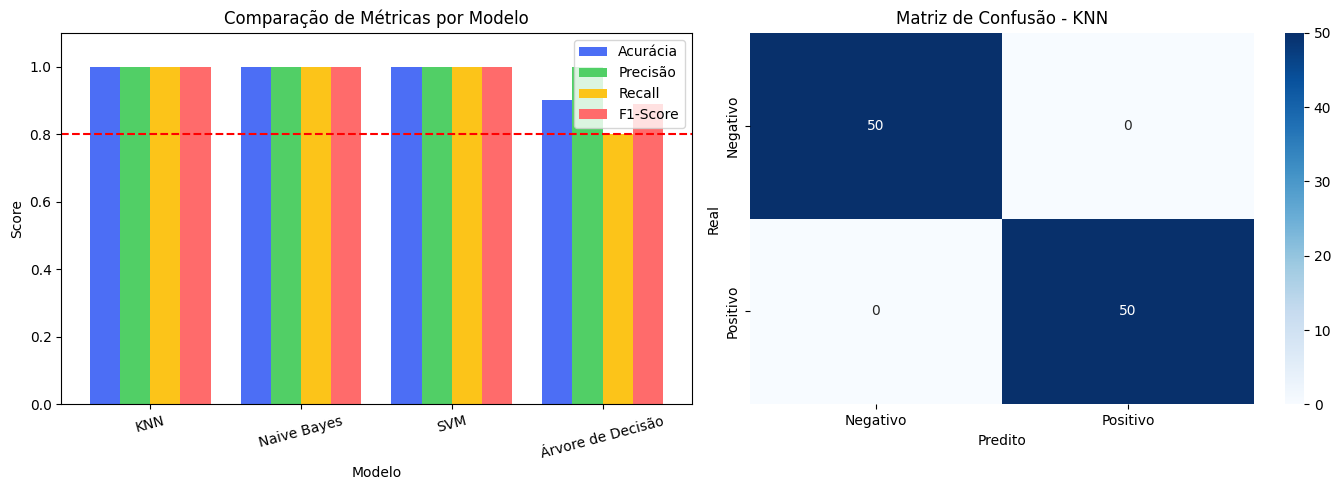


📋 Relatório de Classificação - KNN
              precision    recall  f1-score   support

    Negativo       1.00      1.00      1.00        50
    Positivo       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [8]:
# Visualização dos resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras comparativo
x = np.arange(len(results_df))
width = 0.2

axes[0].bar(x - 1.5*width, results_df['Acurácia'], width, label='Acurácia', color='#4c6ef5')
axes[0].bar(x - 0.5*width, results_df['Precisão'], width, label='Precisão', color='#51cf66')
axes[0].bar(x + 0.5*width, results_df['Recall'], width, label='Recall', color='#fcc419')
axes[0].bar(x + 1.5*width, results_df['F1-Score'], width, label='F1-Score', color='#ff6b6b')

axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('Score')
axes[0].set_title('Comparação de Métricas por Modelo')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Modelo'], rotation=15)
axes[0].legend()
axes[0].axhline(y=0.8, color='red', linestyle='--', label='Threshold 80%')
axes[0].set_ylim(0, 1.1)

# Matriz de confusão do melhor modelo
best_predictions = results[best_model_name]['predictions']
cm = confusion_matrix(y_test, best_predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
axes[1].set_title(f'Matriz de Confusão - {best_model_name}')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Relatório de classificação detalhado
print(f"\n📋 Relatório de Classificação - {best_model_name}")
print("=" * 50)
print(classification_report(y_test, best_predictions,
                            target_names=['Negativo', 'Positivo']))

## 8. Exportação do Melhor Modelo

Vamos salvar o melhor modelo e o vetorizador TF-IDF para uso na aplicação web.

**Arquivos exportados:**
- `sentiment_model.pkl`: Modelo treinado
- `vectorizer.pkl`: Vetorizador TF-IDF (necessário para processar novos textos)

In [9]:
# Selecionar o melhor modelo
best_model = results[best_model_name]['model']

# Salvar modelo
joblib.dump(best_model, 'sentiment_model.pkl')
print(f"✅ Modelo salvo: sentiment_model.pkl")

# Salvar vetorizador
joblib.dump(tfidf_vectorizer, 'vectorizer.pkl')
print(f"✅ Vetorizador salvo: vectorizer.pkl")

# Salvar também os resultados para referência
results_df.to_csv('model_results.csv', index=False)
print(f"✅ Resultados salvos: model_results.csv")

print("\n📦 Arquivos prontos para download!")
print("   Copie esses arquivos para a pasta backend/model/")

✅ Modelo salvo: sentiment_model.pkl
✅ Vetorizador salvo: vectorizer.pkl
✅ Resultados salvos: model_results.csv

📦 Arquivos prontos para download!
   Copie esses arquivos para a pasta backend/model/


In [10]:
# Download dos arquivos (apenas no Colab)
try:
    from google.colab import files
    files.download('sentiment_model.pkl')
    files.download('vectorizer.pkl')
    files.download('model_results.csv')
    print("\n✅ Downloads iniciados!")
except:
    print("\n⚠️ Não está no Colab. Arquivos salvos localmente.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloads iniciados!


## 9. Teste do Modelo Exportado

Vamos testar se o modelo exportado funciona corretamente carregando-o novamente.

In [11]:
# Carregar modelo e vetorizador
loaded_model = joblib.load('sentiment_model.pkl')
loaded_vectorizer = joblib.load('vectorizer.pkl')

# Função de predição
def predict_sentiment(text):
    """
    Prediz o sentimento de uma review.

    Args:
        text: Review em texto

    Returns:
        dict: Sentimento e confiança
    """
    # Pré-processar
    cleaned = preprocess_text(text)

    # Vetorizar
    vectorized = loaded_vectorizer.transform([cleaned])

    # Predizer
    prediction = loaded_model.predict(vectorized)[0]

    return {
        'text': text,
        'sentiment': 'Positivo' if prediction == 1 else 'Negativo',
        'sentiment_code': int(prediction)
    }

# Testar com algumas reviews EM PORTUGUÊS
test_reviews = [
    "Este jogo é absolutamente fantástico! Eu amo!",
    "Experiência terrível, cheio de bugs e travamentos.",
    "Gráficos ótimos mas a jogabilidade é chata.",
    "Melhor jogo de todos! 10/10 recomendo!",
    "Desperdício de dinheiro, não comprem esse lixo."
]

print("🧪 TESTE DO MODELO EXPORTADO")
print("=" * 60)

for review in test_reviews:
    result = predict_sentiment(review)
    emoji = "✅" if result['sentiment'] == 'Positivo' else "❌"
    print(f"\n{emoji} {result['sentiment']}")
    print(f"   \"{review}\"")

print("\n" + "=" * 60)
print("✅ Modelo funcionando corretamente!")

🧪 TESTE DO MODELO EXPORTADO

✅ Positivo
   "Este jogo é absolutamente fantástico! Eu amo!"

❌ Negativo
   "Experiência terrível, cheio de bugs e travamentos."

❌ Negativo
   "Gráficos ótimos mas a jogabilidade é chata."

✅ Positivo
   "Melhor jogo de todos! 10/10 recomendo!"

❌ Negativo
   "Desperdício de dinheiro, não comprem esse lixo."

✅ Modelo funcionando corretamente!


---

## ✅ Conclusão

### O que foi feito:
1. ✅ Carregamos e exploramos o dataset de reviews de jogos
2. ✅ Pré-processamos o texto (limpeza, stopwords, lemmatization)
3. ✅ Vetorizamos com TF-IDF
4. ✅ Treinamos 4 modelos: KNN, Árvore de Decisão, Naive Bayes e SVM
5. ✅ Comparamos métricas e selecionamos o melhor modelo
6. ✅ Exportamos o modelo para uso na aplicação

### Próximos passos:
1. Copiar `sentiment_model.pkl` e `vectorizer.pkl` para `backend/model/`
2. Executar o backend (FastAPI)
3. Abrir o frontend e testar a classificação

---